# Antibody Developability Optimization — Evaluation (REVISED with ProtAttBA)

Evaluates four conditions across all test antibodies (fold 1, ~49 antibodies):

| Condition | Description |
|---|---|
| **Parent** | Original clinical mAb sequence |
| **Baseline** | AbLang2 MLM + oracle selection, no flow model |
| **Flow-only** | Flow-conditioned sampling, no binding guidance |
| **Guided** | Flow-conditioned + binding-guided sampling, oracle-selected |

**Binding affinity metric: ProtAttBA ΔΔG**
- ProtAttBA (Liu et al. 2025) predicts ΔΔG(mutant vs wildtype) from sequence alone.
- Input: antibody (wt_light+wt_heavy concatenated), antigen, antibody_mut, antigen_mut (same)
- Negative ΔΔG = variant binds better than parent (improved).
- Trained on AB1101 multi-site mutations (most relevant to CDR3 swaps).
- Section 2 downloads ESM2-650m from HuggingFace and trains ProtAttBA (~5–15 min on T4).

> Runtime → **T4 GPU**

**Key fixes vs previous version:**
1. ESM2-650m weights auto-downloaded from HuggingFace (`facebook/esm2_t33_650M_UR50D`)
2. `eval.py` file-path routing bypassed — we call the model directly in Python (no subprocess)
3. Inference CSV formatted to match `read_AB_csv` expected columns exactly
4. Training uses `trainer_sigmul.py` with `data_name=AB1101`, `data_folder=sigmul_data`
5. Checkpoint reuse: if already trained, skip training

In [1]:
!pip install -q igfold
!pip install -q ablang2 scikit-learn scipy matplotlib joblib
!pip install -q pytorch-lightning torchmetrics transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.3/800.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.5 MB/s eta 0:00:00


In [2]:
import os, json, subprocess, warnings, ast, glob, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, spearmanr
import joblib

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/2026 Spring/BMI 702/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs'
STRUCT_DIR  = f'{PROJECT_DIR}/structures'
FOLDX_WORK  = f'{PROJECT_DIR}/foldx_work'
FOLDX_BIN   = f'{PROJECT_DIR}/foldx'
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

for d in [STRUCT_DIR, FOLDX_WORK]:
    os.makedirs(d, exist_ok=True)

COL_VH   = 'vh_protein_sequence'
COL_VL   = 'vl_protein_sequence'
COL_NAME = 'antibody_name'
AA_VOCAB = list('ACDEFGHIKLMNPQRSTVWY')
CACHE    = lambda name: f'{PROJECT_DIR}/{name}'

NO_ANTIGEN_ABS  = {'panobacumab', 'racotumomab'}
ESM2_DIM        = 1280
ANTIGEN_MAX_LEN = 512
SCORER_HIDDEN   = 128
SCORER_HEADS    = 4
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


# ─────────────────────────────────────────────────────────────────────────────
# Section 1 — Load All Pipeline Artifacts
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
compare_df = pd.read_csv(f'{EVAL_DIR}/compare_df.csv')
seq_df     = pd.read_csv(f'{EVAL_DIR}/seq_df.csv')
df         = pd.read_csv(f'{EVAL_DIR}/df_sequences.csv')
print(f'compare_df: {compare_df.shape}')
print(f'Columns: {compare_df.columns.tolist()}')

with open(f'{EVAL_DIR}/cdr3_idx.json') as fh:
    cdr3_raw = json.load(fh)
df['h_cdr3_idx'] = [cdr3_raw.get(str(i), []) for i in range(len(df))]

compare_df_binding = compare_df[
    ~compare_df['ab_name'].str.lower().isin(NO_ANTIGEN_ABS)
].reset_index(drop=True)
print(f'All: {len(compare_df)}  |  With antigen: {len(compare_df_binding)}')

compare_df: (50, 23)
Columns: ['ab_name', 'parent_vh', 'parent_vl', 'parent_cdr3', 'guided_cdr3', 'guided_vh', 'flow_only_cdr3', 'flow_only_vh', 'oracle_hic_parent', 'oracle_sins_parent', 'oracle_hic_guided', 'oracle_sins_guided', 'oracle_hic_flow_only', 'oracle_sins_flow_only', 'binding_parent', 'binding_guided', 'binding_flow_only', 'h_cdr3_idx', 'oracle_hic_baseline', 'oracle_sins_baseline', 'baseline_cdr3', 'baseline_vh', 'binding_baseline']
All: 50  |  With antigen: 49


In [4]:
oracle_hic  = joblib.load(f'{EVAL_DIR}/oracle_hic.pkl')
oracle_sins = joblib.load(f'{EVAL_DIR}/oracle_sins.pkl')
full_scaler = joblib.load(f'{EVAL_DIR}/full_scaler.pkl')
pls_model   = joblib.load(f'{EVAL_DIR}/pls_model.pkl')
pls_scaler  = joblib.load(f'{EVAL_DIR}/pls_scaler.pkl')
dev_scaler  = joblib.load(f'{EVAL_DIR}/dev_scaler.pkl')

from sklearn.decomposition import PCA
pca      = joblib.load(f'{EVAL_DIR}/pca_cdr3.pkl')
full_pca = joblib.load(f'{EVAL_DIR}/pca_full.pkl')

y_hic_train  = np.load(f'{EVAL_DIR}/y_hic_train.npy')
y_sins_train = np.load(f'{EVAL_DIR}/y_sins_train.npy')
y_hic_test   = np.load(f'{EVAL_DIR}/y_hic_test.npy')
y_sins_test  = np.load(f'{EVAL_DIR}/y_sins_test.npy')
train_idx = np.load(f'{EVAL_DIR}/train_idx.npy')
test_idx  = np.load(f'{EVAL_DIR}/test_idx.npy')

# Load antigen sequences for each clinical mAb
df_antigens = pd.read_csv(f'{PROJECT_DIR}/clinical_mabs_with_antigens.csv')
name_to_antigen = {}
for _, row in df_antigens.iterrows():
    name = str(row.get(COL_NAME, '')).lower()
    ag   = row.get('antigen_seq', None) or row.get('Ag_seq', None)
    if isinstance(ag, str) and ag:
        name_to_antigen[name] = ag

print(f'Antigen sequences available for {len(name_to_antigen)} antibodies.')
print('All artifacts loaded.')

Antigen sequences available for 0 antibodies.
All artifacts loaded.


In [5]:
import ablang2
ablang = ablang2.pretrained(model_to_use='ablang2-paired',
                             random_init=False, ncpu=1, device=DEVICE)
ablang.freeze()

def oracle_score(vh_seq, vl_seq):
    with torch.no_grad():
        emb = ablang([(vh_seq, vl_seq)], mode='seqcoding')
    emb_sc = full_scaler.transform(np.array(emb).reshape(1, -1))
    return {'hic': float(oracle_hic.predict(emb_sc)[0]),
            'sins': float(oracle_sins.predict(emb_sc)[0])}

print('AbLang2 and oracle_score() loaded.')

AbLang2 and oracle_score() loaded.


# ─────────────────────────────────────────────────────────────────────────────
# Section 2 — ProtAttBA ΔΔG Evaluation
#
# FIX SUMMARY (vs broken original):
#   2a  Clone/unzip ProtAttBA; download ESM2-650m from HuggingFace
#   2b  Train on AB1101 sigmul data using trainer_sigmul.py (skip if ckpt exists)
#   2c  Format compare_df pairs with ALL required columns for read_AB_csv
#   2d  Run inference using Python API directly (bypasses eval.py filename routing)
#   2e  Parse predictions and attach ddG_protattba_* columns
# ─────────────────────────────────────────────────────────────────────────────

In [6]:
# ── 2a: Set up ProtAttBA repo ─────────────────────────────────────────────────
PROTATTBA_DIR = '/content/ProtAttBA'

# Option A: uploaded ZIP (preferred — avoids network clone)
if not os.path.exists(PROTATTBA_DIR):
    zip_candidates = [
        '/content/ProtAttBA.zip',
        f'{PROJECT_DIR}/ProtAttBA.zip',
    ]
    zip_path = next((p for p in zip_candidates if os.path.exists(p)), None)
    if zip_path:
        print(f'Extracting from {zip_path}...')
        import zipfile
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall('/content')
        print('Extracted ProtAttBA.')
    else:
        print('ZIP not found — cloning from GitHub...')
        result = subprocess.run(
            ['git', 'clone', 'https://github.com/code4luck/ProtAttBA.git', PROTATTBA_DIR],
            capture_output=True, text=True
        )
        print(result.stdout); print(result.stderr)
else:
    print('ProtAttBA directory already exists.')

SIGMUL_DIR = f'{PROTATTBA_DIR}/seq-identity_sig-mul'
print(f'SIGMUL_DIR: {SIGMUL_DIR}')
print('Files:', os.listdir(SIGMUL_DIR))

ZIP not found — cloning from GitHub...

Cloning into '/content/ProtAttBA'...

SIGMUL_DIR: /content/ProtAttBA/seq-identity_sig-mul
Files: ['result_log', 'model.py', 'trainer_identity.py', 'lit_model.py', 'eval.py', 'dataset.py', 'data', 'results', 'trainer_sigmul.py', 'utils', 'scripts', 'model_module', 'model']


In [7]:
# Install ProtAttBA requirements
req_path = f'{PROTATTBA_DIR}/requirments.txt'
if os.path.exists(req_path):
    subprocess.run(['pip', 'install', '-q', '-r', req_path], capture_output=True)
    print('Requirements installed.')

# ── FIX: Download ESM2-650m weights from HuggingFace ─────────────────────────
# The repo model/readme.txt says to download from HuggingFace.
# We download into the expected path: {SIGMUL_DIR}/model/esm2_650m
ESM2_LOCAL_PATH = f'{SIGMUL_DIR}/model/esm2_650m'

if not os.path.exists(ESM2_LOCAL_PATH) or not os.listdir(ESM2_LOCAL_PATH):
    os.makedirs(ESM2_LOCAL_PATH, exist_ok=True)
    print(f'Downloading ESM2-650m from HuggingFace → {ESM2_LOCAL_PATH}')
    print('(This downloads ~2.5 GB — takes a few minutes on Colab)')
    from transformers import AutoTokenizer, EsmModel
    tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t33_650M_UR50D')
    model_esm = EsmModel.from_pretrained('facebook/esm2_t33_650M_UR50D')
    tokenizer.save_pretrained(ESM2_LOCAL_PATH)
    model_esm.save_pretrained(ESM2_LOCAL_PATH)
    del model_esm  # free memory
    import gc; gc.collect(); torch.cuda.empty_cache()
    print(f'ESM2-650m saved to {ESM2_LOCAL_PATH}')
else:
    print(f'ESM2-650m already present at {ESM2_LOCAL_PATH}')

Requirements installed.
(This downloads ~2.5 GB — takes a few minutes on Colab)


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ESM2-650m saved to /content/ProtAttBA/seq-identity_sig-mul/model/esm2_650m


In [8]:
# ── Verify AB1101 training data exists and inspect columns ────────────────────
ab1101_sigmul_single = f'{SIGMUL_DIR}/data/sigmul_data/AB1101_single.csv'
ab1101_sigmul_multi  = f'{SIGMUL_DIR}/data/sigmul_data/AB1101_multiple.csv'

ab1101_df = pd.read_csv(ab1101_sigmul_single)
print(f'AB1101_single shape: {ab1101_df.shape}')
print(f'Columns: {ab1101_df.columns.tolist()}')
print(ab1101_df.head(2))

# Confirmed column names (from actual file inspection):
COL_HEAVY_WT  = 'antibody_heavy_seq'
COL_LIGHT_WT  = 'antibody_light_seq'
COL_ANTIGEN_A = 'antigen_a_seq'
COL_ANTIGEN_B = 'antigen_b_seq'       # may be empty — filled with '' for single-chain antigens
COL_HEAVY_MUT = 'antibody_heavy_seq_mut'
COL_LIGHT_MUT = 'antibody_light_seq_mut'
COL_AGa_MUT   = 'antigen_a_seq_mut'   # same as WT for our case (antigen unchanged)
COL_AGb_MUT   = 'antigen_b_seq_mut'   # same as WT for our case
COL_DDG       = 'ddG'
print('Column names confirmed.')

AB1101_single shape: (645, 31)
Columns: ['ab', 'ag', 'PDB', 'Partners', 'Protein-1', 'Protein-2', 'Mutation', 'Mutation2', 'antibody_light_seq', 'antibody_heavy_seq', 'antigen_a_seq', 'antigen_b_seq', 'antibody_light_seq_mut', 'antibody_heavy_seq_mut', 'antigen_a_seq_mut', 'antigen_b_seq_mut', 'ddG', 'PDB Res. (Angstroms)', 'PDB R-value', 'PDB R-free', 'PDB pH', 'PDB T (K)', 'PDB MolProbity clashscore', 'PDB DOI', 'Assay Name', 'Assay pH', 'Assay Temp (Celcius)', 'Unnamed: 27', 'abl_length', 'abh_length', 'ag_length']
    ab  ag   PDB Partners Protein-1              Protein-2 Mutation Mutation2  \
0  NaN NaN  1AK4      A_D   huCyc-A  HIV-1 CAPSID (N-Term)  D:A488G   D:A488G   
1  NaN NaN  1AK4      A_D   huCyc-A  HIV-1 CAPSID (N-Term)  D:A488V   D:A488V   

                                  antibody_light_seq antibody_heavy_seq  ...  \
0  MVNPTVFFDIAVDGEPLGRVSFELFADKVPKTAENFRALSTGEKGF...                NaN  ...   
1  MVNPTVFFDIAVDGEPLGRVSFELFADKVPKTAENFRALSTGEKGF...                NaN 

In [9]:
# ── 2b: Train ProtAttBA on AB1101 (sigmul split) ─────────────────────────────
# Uses trainer_sigmul.py with data_name=AB1101 and data_folder=sigmul_data.
# This is the sig→mul generalization setup from the paper.
# Skips training if a checkpoint already exists.

PROTATTBA_CKPT_DIR = f'{PROJECT_DIR}/protattba_ckpt'
os.makedirs(PROTATTBA_CKPT_DIR, exist_ok=True)

# Find any existing checkpoint
existing_ckpts = glob.glob(f'{PROTATTBA_CKPT_DIR}/**/*.ckpt', recursive=True)
PROTATTBA_CKPT = existing_ckpts[0] if existing_ckpts else None

if PROTATTBA_CKPT and os.path.exists(PROTATTBA_CKPT):
    print(f'Checkpoint found — skipping training: {PROTATTBA_CKPT}')
else:
    print('No checkpoint found — training ProtAttBA on AB1101 sigmul data...')
    print('Expected time: ~5–15 min on T4 GPU')

    # FIX: trainer_sigmul.py uses sig_mul_utils.load_data which expects
    # data_folder containing AB1101_single.csv and AB1101_multiple.csv
    # and data_name="AB1101"
    train_script = f'{SIGMUL_DIR}/trainer_sigmul.py'
    data_folder  = f'{SIGMUL_DIR}/data/sigmul_data'

    result = subprocess.run(
        ['python', train_script,
         '--model_locate',           f'{SIGMUL_DIR}/model/esm2_650m',
         '--data_folder',            data_folder,
         '--data_name',              'AB1101',
         '--batch_size',             '8',
         '--max_epochs',             '30',          # reduced for speed; paper uses 150
         '--patience',               '10',
         '--lr',                     '3e-5',
         '--devices',                '1',
         '--strategy',               'auto',
         '--accumulate_grad_batches','2',
         '--hidden_size',            '1280',
         '--num_heads',              '4',
         '--dropout',                '0.1',
         '--loss',                   'mse',
         '--monitor',                'val_pearson_corr',
         '--freeze_backbone',                         # freeze ESM2 — much faster
         '--seed',                   '3407',
        ],
        cwd=SIGMUL_DIR,
        capture_output=True, text=True, timeout=3600,
        env={**os.environ, 'PYTHONPATH': SIGMUL_DIR}
    )
    print(result.stdout[-4000:] if len(result.stdout) > 4000 else result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])

    # Find the saved checkpoint
    saved_ckpts = (glob.glob(f'{SIGMUL_DIR}/**/*.ckpt', recursive=True) +
                   glob.glob(f'/content/**/*.ckpt', recursive=True))
    if saved_ckpts:
        # pick best (highest pearson_corr if in name, else first)
        best = sorted(saved_ckpts, key=lambda p: ('pearson' in p), reverse=True)[0]
        PROTATTBA_CKPT = f'{PROTATTBA_CKPT_DIR}/best_model.ckpt'
        shutil.copy(best, PROTATTBA_CKPT)
        print(f'Checkpoint saved → {PROTATTBA_CKPT}')
    else:
        print('WARNING: No .ckpt file found after training. Check stderr above.')
        PROTATTBA_CKPT = None

print(f'PROTATTBA_CKPT = {PROTATTBA_CKPT}')

No checkpoint found — training ProtAttBA on AB1101 sigmul data...
Expected time: ~5–15 min on T4 GPU
del 27 records
del 23 records
args:  Namespace(model_locate='/content/ProtAttBA/seq-identity_sig-mul/model/esm2_650m', num_workers=4, batch_size=8, data_folder='/content/ProtAttBA/seq-identity_sig-mul/data/sigmul_data', data_name='AB1101', max_length=None, hidden_size=1280, num_heads=4, dropout=0.1, out_dim=1, freeze_backbone=True, loss='mse', monitor='val_pearson_corr', devices=1, accelerator='gpu', strategy='auto', num_nodes=1, max_epochs=30, patience=10, lr=3e-05, accumulate_grad_batches=2, gradient_clip_val=5.0, gradient_clip_algorithm='value', seed=3407, precision='32', val_ratio=0.1, rm_abnormal=True)

STDERR: kwargs)
Traceback (most recent call last):
  File "/content/ProtAttBA/seq-identity_sig-mul/trainer_sigmul.py", line 134, in <module>
    main()
  File "/content/ProtAttBA/seq-identity_sig-mul/trainer_sigmul.py", line 115, in main
    trainer = pl.Trainer(
              ^^^^^

In [10]:
# ── 2c: Format inference CSV with ALL columns expected by read_AB_csv ─────────
#
# FIX: The original notebook was missing required columns:
#   antigen_b_seq, antigen_b_seq_mut, PDB, Mutation
# read_AB_csv uses pd.read_csv(..., usecols=[...]) and will crash without these.
#
# For our clinical mAbs:
#   - antigen_b_seq / antigen_b_seq_mut = '' (single-chain antigen, no B chain)
#   - antigen_a_seq_mut = antigen_a_seq  (antigen is unchanged)
#   - antibody_light_seq_mut = antibody_light_seq  (only heavy CDR3 changes)

INFERENCE_CSV = f'{PROTATTBA_CKPT_DIR}/AB_inference_input.csv'  # "AB" in name for routing

inference_rows = []
condition_cols = [
    ('baseline',  'baseline_vh'),
    ('flow_only', 'flow_only_vh'),
    ('guided',    'guided_vh'),
]

skipped = []
for _, row in compare_df_binding.iterrows():
    ab_name   = row['ab_name']
    ag_seq    = name_to_antigen.get(ab_name.lower(), None)
    if not isinstance(ag_seq, str) or not ag_seq:
        skipped.append(ab_name)
        continue

    parent_vh = row.get('parent_vh', '')
    parent_vl = row.get('parent_vl', '')
    if not isinstance(parent_vh, str) or not parent_vh:
        skipped.append(ab_name)
        continue

    for label, vh_col in condition_cols:
        mut_vh = row.get(vh_col, '')
        if not isinstance(mut_vh, str) or not mut_vh:
            continue
        inference_rows.append({
            # Required by read_AB_csv (usecols list):
            'PDB':                    ab_name,
            'Mutation':               f'{label}',
            'antibody_light_seq':     parent_vl,
            'antibody_heavy_seq':     parent_vh,
            'antigen_a_seq':          ag_seq,
            'antigen_b_seq':          '',           # no second antigen chain
            'antibody_light_seq_mut': parent_vl,    # light chain unchanged
            'antibody_heavy_seq_mut': mut_vh,
            'antigen_a_seq_mut':      ag_seq,       # antigen unchanged
            'antigen_b_seq_mut':      '',
            'ddG':                    0.0,           # placeholder for inference
            # Extra metadata (not used by model):
            'ab_name':                ab_name,
            'condition':              label,
        })

inference_df = pd.DataFrame(inference_rows)
inference_df.to_csv(INFERENCE_CSV, index=False)
print(f'Skipped antibodies (no antigen): {skipped}')
print(f'Saved inference input: {INFERENCE_CSV}  ({len(inference_df)} rows)')
print(f'Conditions: {inference_df["condition"].value_counts().to_dict()}')
print(inference_df[['ab_name','condition','antibody_heavy_seq','antibody_heavy_seq_mut']].head(3))

Skipped antibodies (no antigen): ['abagovomab', 'abituzumab', 'abrilumab', 'amatuximab', 'basiliximab', 'bavituximab', 'belantamab', 'bemarituzumab', 'benralizumab', 'blosozumab', 'bococizumab', 'brontictuzumab', 'burosumab', 'coltuximab', 'crizanlizumab', 'daclizumab', 'eculizumab', 'emactuzumab', 'emibetuzumab', 'enokizumab', 'epratuzumab', 'fasinumab', 'fletikumab', 'galcanezumab', 'gemtuzumab', 'imgatuzumab', 'inotuzumab', 'lampalizumab', 'lintuzumab', 'loncastuximab', 'matuzumab', 'mirikizumab', 'monalizumab', 'muromonab', 'natalizumab', 'nimotuzumab', 'obiltoxaximab', 'omburtamab', 'pidilizumab', 'risankizumab', 'rituximab', 'romosozumab', 'selicrelumab', 'sintilimab', 'tildrakizumab', 'ublituximab', 'vadastuximab', 'veltuzumab', 'visilizumab']
Saved inference input: /content/drive/MyDrive/2026 Spring/BMI 702/project/protattba_ckpt/AB_inference_input.csv  (0 rows)


KeyError: 'condition'

In [ ]:
# ── 2d: Run ProtAttBA inference via Python API (bypass eval.py routing) ───────
#
# FIX: eval.py load_eval_dataset() routes by filename:
#   if "S1131" in filt_path → get_s1131_data
#   elif "AB" in filt_path  → get_AB_pair_data
#   else                    → raises ValueError
#
# We already named the CSV "AB_inference_input.csv" so "AB" IS in the path.
# But to be safe (and avoid the rm_abnormal bug in data_utils.py), we call
# the model directly in Python — no subprocess, no filename routing issues.
#
# This also avoids the eval.py bug where it looks for antigen_b_seq columns
# in our single-chain antigen data (cat_seq handles NaN gracefully).

import sys
sys.path.insert(0, SIGMUL_DIR)

protattba_ddg_available = False
INFERENCE_OUT_DIR = f'{PROTATTBA_CKPT_DIR}/preds'
os.makedirs(INFERENCE_OUT_DIR, exist_ok=True)

if PROTATTBA_CKPT and os.path.exists(PROTATTBA_CKPT):
    print(f'Loading checkpoint: {PROTATTBA_CKPT}')

    from lit_model import LitModel
    from dataset import SeqDataset
    from torch.utils.data import DataLoader
    from transformers import AutoTokenizer

    # ── Load model ────────────────────────────────────────────────────────────
    lit = LitModel.load_from_checkpoint(PROTATTBA_CKPT)
    prot_model = lit.model
    prot_model.eval()
    prot_model.to(DEVICE)
    print('Model loaded.')

    # ── Tokenizer ─────────────────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(f'{SIGMUL_DIR}/model/esm2_650m')

    # ── Build sequences (same as data_utils.cat_seq logic) ────────────────────
    def cat_seq(s1, s2):
        if not isinstance(s1, str) or not s1: return s2
        if not isinstance(s2, str) or not s2: return s1
        return s1 + s2

    wt_ab_seqs, mt_ab_seqs, wt_ag_seqs, mt_ag_seqs, placeholders = [], [], [], [], []
    for _, row in inference_df.iterrows():
        wt_ab_seqs.append(cat_seq(row['antibody_light_seq'],     row['antibody_heavy_seq']))
        mt_ab_seqs.append(cat_seq(row['antibody_light_seq_mut'], row['antibody_heavy_seq_mut']))
        wt_ag_seqs.append(cat_seq(row['antigen_a_seq'],          row['antigen_b_seq']))
        mt_ag_seqs.append(cat_seq(row['antigen_a_seq_mut'],      row['antigen_b_seq_mut']))
        placeholders.append(0.0)

    dataset = SeqDataset(
        wt_ab_seqs=wt_ab_seqs,
        mt_ab_seqs=mt_ab_seqs,
        wt_ag_seqs=wt_ag_seqs,
        mt_ag_seqs=mt_ag_seqs,
        labels=placeholders,
    )

    MAX_LEN = 1024  # truncate long sequences

    def collate_fn(batch):
        wt_ab, mt_ab, wt_ag, mt_ag, labels = zip(*batch)
        def tok(seqs):
            return tokenizer(list(seqs), padding=True, return_tensors='pt',
                             max_length=MAX_LEN, truncation=True)
        wt_ab_enc = tok(wt_ab); mt_ab_enc = tok(mt_ab)
        wt_ag_enc = tok(wt_ag); mt_ag_enc = tok(mt_ag)
        return {
            'wt_ab_inputs_ids':  wt_ab_enc['input_ids'],
            'wt_ab_inputs_mask': wt_ab_enc['attention_mask'],
            'mut_ab_inputs_ids': mt_ab_enc['input_ids'],
            'mt_ab_inputs_mask': mt_ab_enc['attention_mask'],
            'wt_ag_inputs_ids':  wt_ag_enc['input_ids'],
            'wt_ag_inputs_mask': wt_ag_enc['attention_mask'],
            'mut_ag_inputs_ids': mt_ag_enc['input_ids'],
            'mt_ag_inputs_mask': mt_ag_enc['attention_mask'],
            'labels': torch.tensor(labels, dtype=torch.float32),
        }

    loader = DataLoader(dataset, batch_size=8, shuffle=False,
                        num_workers=2, collate_fn=collate_fn)

    preds_list = []
    print('Running inference...')
    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = prot_model(
                wt_ab_inputs_ids=batch['wt_ab_inputs_ids'],
                wt_ab_inputs_mask=batch['wt_ab_inputs_mask'],
                mut_ab_inputs_ids=batch['mut_ab_inputs_ids'],
                mt_ab_inputs_mask=batch['mt_ab_inputs_mask'],
                wt_ag_inputs_ids=batch['wt_ag_inputs_ids'],
                wt_ag_inputs_mask=batch['wt_ag_inputs_mask'],
                mut_ag_inputs_ids=batch['mut_ag_inputs_ids'],
                mt_ag_inputs_mask=batch['mt_ag_inputs_mask'],
            )
            preds_list.extend(outputs.cpu().numpy().tolist())
            if (i + 1) % 5 == 0:
                print(f'  Batch {i+1}/{len(loader)}')

    print(f'Inference complete. {len(preds_list)} predictions.')

    # Save with metadata
    pred_df = inference_df[['ab_name', 'condition']].copy()
    pred_df['preds'] = preds_list
    pred_df['ground_truth'] = 0.0  # placeholder

    save_path = f'{INFERENCE_OUT_DIR}/protattba_predictions.csv'
    pred_df.to_csv(save_path, index=False)
    print(f'Saved predictions → {save_path}')
    protattba_ddg_available = True

else:
    print('No checkpoint available — skipping inference.')
    print(f'PROTATTBA_CKPT = {PROTATTBA_CKPT}')
    pred_df = None

In [ ]:
# ── 2e: Attach ProtAttBA ΔΔG to compare_df ───────────────────────────────────
if protattba_ddg_available and pred_df is not None:
    print(f'Prediction shape: {pred_df.shape}')
    print(pred_df.head(6))

    for label in ['baseline', 'flow_only', 'guided']:
        subset = pred_df[pred_df['condition'] == label][['ab_name', 'preds']].copy()
        subset = subset.rename(columns={'preds': f'ddG_protattba_{label}'})
        compare_df_binding = compare_df_binding.merge(subset, on='ab_name', how='left')
        compare_df         = compare_df.merge(subset, on='ab_name', how='left')

    print('\nProtAttBA ΔΔG (negative = improved binding vs parent):')
    for label in ['baseline', 'flow_only', 'guided']:
        col  = f'ddG_protattba_{label}'
        vals = compare_df_binding[col].dropna()
        improved = (vals < 0).sum()
        print(f'  {label:<12} mean={vals.mean():+.3f} ± {vals.sem():.3f}'
              f'  improved: {improved}/{len(vals)}'
              f'  ({100*improved/max(len(vals),1):.0f}%)')
else:
    print('ProtAttBA output not available — adding NaN placeholders.')
    for label in ['baseline', 'flow_only', 'guided']:
        compare_df_binding[f'ddG_protattba_{label}'] = float('nan')
        compare_df[f'ddG_protattba_{label}']         = float('nan')

In [ ]:
# ── ProtAttBA ΔΔG per-antibody bar chart ─────────────────────────────────────
CONDITIONS_PROT = [
    ('Baseline',  'ddG_protattba_baseline'),
    ('Flow-only', 'ddG_protattba_flow_only'),
    ('Guided',    'ddG_protattba_guided'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, col) in zip(axes, CONDITIONS_PROT):
    vals = compare_df_binding[col].dropna()
    if vals.empty:
        ax.set_title(f'{label} (no data)'); continue
    color = 'steelblue' if label == 'Guided' else (
            'mediumseagreen' if label == 'Flow-only' else 'coral')
    ax.bar(range(len(vals)), sorted(vals.values), color=color, alpha=0.85)
    ax.axhline(0, color='black', lw=1.2, ls='--')
    n_imp = (vals < 0).sum()
    ax.set(xlabel='Antibody (sorted)',
           ylabel='ProtAttBA ΔΔG (kcal/mol)',
           title=f'{label}\nmean={vals.mean():+.3f}  improved={n_imp}/{len(vals)}')
    ax.grid(True, alpha=0.25)

plt.suptitle('ProtAttBA ΔΔG vs Parent  (negative = improved binding)', fontsize=11)
plt.tight_layout()
plt.savefig(CACHE('protattba_ddg_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print('ProtAttBA ΔΔG plot saved.')

In [ ]:
# ── Compute Oracle HIC + SINS for all conditions ──────────────────────────────
CONDITIONS_EVAL = [('Baseline','_baseline'), ('Flow-only','_flow_only'), ('Guided','_guided')]

for label, suffix in [('parent','_parent')] + [(l, s) for l, s in CONDITIONS_EVAL]:
    vh_col = f'parent_vh' if label == 'parent' else f'{label.lower().replace("-","_").replace(" ","_")}_vh'
    # Map label → column name
    col_map = {
        'parent':    'parent_vh',
        'Baseline':  'baseline_vh',
        'Flow-only': 'flow_only_vh',
        'Guided':    'guided_vh',
    }
    vh_col = col_map[label]
    vl_col = 'parent_vl'

    hic_vals  = []
    sins_vals = []
    for _, row in compare_df.iterrows():
        vh = row.get(vh_col, ''); vl = row.get(vl_col, '')
        if isinstance(vh, str) and vh and isinstance(vl, str) and vl:
            s = oracle_score(vh, vl)
            hic_vals.append(s['hic']); sins_vals.append(s['sins'])
        else:
            hic_vals.append(float('nan')); sins_vals.append(float('nan'))

    compare_df[f'oracle_hic{suffix}']  = hic_vals
    compare_df[f'oracle_sins{suffix}'] = sins_vals

print('Oracle scores computed.')
for label, suffix in [('Parent','_parent'), ('Baseline','_baseline'),
                      ('Flow-only','_flow_only'), ('Guided','_guided')]:
    h = pd.Series(compare_df[f'oracle_hic{suffix}']).dropna()
    s = pd.Series(compare_df[f'oracle_sins{suffix}']).dropna()
    print(f'  {label:<12} HIC={h.mean():.3f}±{h.sem():.3f}  SINS={s.mean():.3f}±{s.sem():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# Section 3 — IgFold: Structure Prediction + CDR3 pLDDT
# ─────────────────────────────────────────────────────────────────────────────

In [12]:
import torch.serialization
_true_load = torch.serialization.load

import transformers.tokenization_utils_sentencepiece as _tus
import transformers.models.bert.tokenization_bert as _bert_tok

if not hasattr(_tus, 'Trie'):
    class Trie:
        def __init__(self): self.data = {}
        def add(self, word):
            node = self.data
            for char in word: node = node.setdefault(char, {})
        def split(self, text): return [text]
    _tus.Trie = Trie

if not hasattr(_bert_tok, 'BasicTokenizer'):
    class BasicTokenizer:
        def __init__(self, do_lower_case=True, **kw):
            self.do_lower_case = do_lower_case
        def tokenize(self, text, never_split=None):
            return text.lower().split() if self.do_lower_case else text.split()
    _bert_tok.BasicTokenizer = BasicTokenizer

if not hasattr(_bert_tok, 'WordpieceTokenizer'):
    class WordpieceTokenizer:
        def __init__(self, vocab, unk_token='[UNK]', **kw):
            self.vocab = vocab; self.unk_token = unk_token
        def tokenize(self, text):
            return [text if text in self.vocab else self.unk_token]
    _bert_tok.WordpieceTokenizer = WordpieceTokenizer

_orig_module_getattr = nn.Module.__getattr__
def _module_getattr_patched(self, name):
    if name == 'all_tied_weights_keys': return {}
    return _orig_module_getattr(self, name)
nn.Module.__getattr__ = _module_getattr_patched

from transformers.models.bert.configuration_bert import BertConfig
torch.serialization.add_safe_globals([BertConfig])

def _patched_load(f, *a, **kw):
    kw['weights_only'] = False; return _true_load(f, *a, **kw)

try:
    torch.load = _patched_load
    from igfold import IgFoldRunner
    igfold = IgFoldRunner()
    torch.load = _true_load
    IGFOLD_AVAILABLE = True
    print('IgFold loaded.')
except Exception as e:
    torch.load = _true_load
    IGFOLD_AVAILABLE = False
    print(f'IgFold unavailable ({e}) — pLDDT will be NaN.')


    The code, data, and weights for this work are made available for non-commercial use 
    (including at commercial entities) under the terms of the JHU Academic Software License 
    Agreement. For commercial inquiries, please contact awichma2[at]jhu.edu.
    License: https://github.com/Graylab/IgFold/blob/main/LICENSE.md
    
Loading 4 IgFold models...
Using device: cuda:0
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_1.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_2.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_3.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_5.ckpt...
Successfully loaded 4 IgFold models.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

AntiBERTy LOAD REPORT from: /usr/local/lib/python3.12/dist-packages/antiberty/trained_models/AntiBERTy_md_smooth
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded AntiBERTy model.
IgFold loaded.


In [13]:
pdb_records = []
for _, row in compare_df.iterrows():
    ab_name = row['ab_name']
    rec = {'ab_name': ab_name}
    for variant in ['parent', 'baseline', 'flow_only', 'guided']:
        rec[f'pdb_{variant}']        = None
        rec[f'plddt_cdr3_{variant}'] = float('nan')
        rec[f'plddt_full_{variant}'] = float('nan')
    if IGFOLD_AVAILABLE:
        for variant, vh_col in [('parent','parent_vh'), ('baseline','baseline_vh'),
                                 ('flow_only','flow_only_vh'), ('guided','guided_vh')]:
            vh = row.get(vh_col, ''); vl = row.get('parent_vl', '')
            if not isinstance(vh, str) or not vh: continue
            try:
                pdb_path = f'{STRUCT_DIR}/{ab_name}_{variant}.pdb'
                igfold.fold(sequences={'H': vh, 'L': vl}, pdb_path=pdb_path)
                rec[f'pdb_{variant}'] = pdb_path
                print(f'  ✓ {ab_name} [{variant}]')
            except Exception as e:
                print(f'  ✗ {ab_name} [{variant}]: {e}')
    pdb_records.append(rec)

pdb_df = pd.DataFrame(pdb_records)
print(f'pdb_df: {pdb_df.shape}')

  ✗ abagovomab [parent]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abagovomab [baseline]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abagovomab [flow_only]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abagovomab [guided]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abituzumab [parent]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abituzumab [baseline]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abituzumab [flow_only]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abituzumab [guided]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abrilumab [parent]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abrilumab [baseline]: IgFoldRunner.fold() got an unexpected keyword argument 'pdb_path'
  ✗ abrilumab [flow_only]: IgFoldRunner.fold() got an unexpected keyword argumen

# ─────────────────────────────────────────────────────────────────────────────
# Section 4 — FoldX ΔΔG  (chain 'H' — IgFold convention)
# ─────────────────────────────────────────────────────────────────────────────

In [14]:
foldx_available = os.path.exists(FOLDX_BIN)
print(f'FoldX: {"found ✓" if foldx_available else "NOT found — skipping"}')

def build_mutation_string(parent_cdr3, variant_cdr3, cdr3_positions, chain='H'):
    if parent_cdr3 == variant_cdr3: return None
    muts = []
    for orig, new, pos in zip(parent_cdr3, variant_cdr3, cdr3_positions):
        if orig != new:
            muts.append(f'{orig}{chain}{pos+1}{new}')
    return ','.join(muts) + ';' if muts else None

def run_foldx(parent_pdb, mut_string, label):
    if not foldx_available or parent_pdb is None: return float('nan')
    if mut_string is None: return 0.0
    mut_file = f'{FOLDX_WORK}/mutlist_{label}.txt'
    with open(mut_file, 'w') as fh: fh.write(mut_string + '\n')
    pdb_name = os.path.basename(parent_pdb)
    cmd = [FOLDX_BIN, '--command=BuildModel',
           f'--pdb={pdb_name}', f'--pdb-dir={os.path.dirname(parent_pdb)}',
           f'--mutant-file={mut_file}', f'--output-dir={FOLDX_WORK}',
           '--numberOfRuns=3', '--out-pdb=false', '--verbosity=0']
    try:
        out = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
        for line in out.stdout.split('\n'):
            if line.strip().startswith('Total'): return float(line.split()[1])
        dif = f'{FOLDX_WORK}/Dif_{pdb_name.replace(".pdb","")}_1.fxout'
        if os.path.exists(dif):
            with open(dif) as fh:
                for line in fh.readlines()[9:]:
                    parts = line.strip().split('\t')
                    if len(parts) >= 2: return float(parts[1])
    except Exception as exc:
        print(f'  FoldX failed [{label}]: {exc}')
    return float('nan')

DDG_CONDITIONS = [('baseline','baseline_cdr3'), ('flow_only','flow_only_cdr3'), ('guided','guided_cdr3')]
ddg_records = []
for _, pdb_row in pdb_df.iterrows():
    ab_name  = pdb_row['ab_name']
    comp_row = compare_df[compare_df['ab_name'] == ab_name]
    if not len(comp_row): continue
    comp_row    = comp_row.iloc[0]
    parent_pdb  = pdb_row.get('pdb_parent')
    parent_cdr3 = comp_row.get('parent_cdr3', '')
    df_rows     = df[df[COL_NAME] == ab_name]
    cdr3_idx    = df_rows['h_cdr3_idx'].values[0] if len(df_rows) else []
    rec = {'ab_name': ab_name}
    for variant, cdr3_col in DDG_CONDITIONS:
        var_cdr3 = comp_row.get(cdr3_col, '')
        if (not isinstance(var_cdr3, str) or not var_cdr3
                or not isinstance(parent_cdr3, str)
                or len(var_cdr3) != len(parent_cdr3)
                or parent_pdb is None):
            rec[f'ddg_foldx_{variant}'] = float('nan'); continue
        mut = build_mutation_string(parent_cdr3, var_cdr3, cdr3_idx, chain='H')
        ddg = run_foldx(parent_pdb, mut, f'{ab_name}_{variant}')
        rec[f'ddg_foldx_{variant}'] = ddg
    ddg_records.append(rec)

ddg_df = pd.DataFrame(ddg_records) if ddg_records else pd.DataFrame({'ab_name': compare_df['ab_name']})
print('FoldX section complete.')

FoldX: found ✓
FoldX section complete.


# ─────────────────────────────────────────────────────────────────────────────
# Section 5 — CamSol + SAP on full VH sequences
# ─────────────────────────────────────────────────────────────────────────────

In [15]:
def camsol(seq):
    """Sliding-window solubility proxy — applied to full VH."""
    if not isinstance(seq, str) or len(seq) < 5: return float('nan')
    HYDROPHILICITY = {
        'D': 2.5,'E': 2.5,'K': 2.5,'R': 2.5,'H': 1.5,
        'N': 1.0,'Q': 1.0,'S': 1.0,'T': 1.0,
        'G': 0.0,'A': -0.5,'P': -0.5,
        'C': -1.0,'M': -1.0,'V': -1.5,'I': -1.5,'L': -1.5,
        'F': -2.0,'Y': -2.0,'W': -2.5,
    }
    scores = [HYDROPHILICITY.get(aa, 0) for aa in seq.upper()]
    window = 7
    if len(scores) < window: return float(np.mean(scores))
    return float(np.mean([np.mean(scores[i:i+window]) for i in range(len(scores)-window+1)]))

def sap_score(seq):
    """Hydrophobic patch aggregation proxy — applied to full VH."""
    if not isinstance(seq, str) or len(seq) < 5: return float('nan')
    HYDROPHOBIC = set('VILMFYW')
    scores = [1.0 if aa in HYDROPHOBIC else 0.0 for aa in seq.upper()]
    window = 5
    if len(scores) < window: return float(np.mean(scores))
    return float(np.mean([np.mean(scores[i:i+window]) for i in range(len(scores)-window+1)]))

for label, vh_col in [('parent','parent_vh'), ('baseline','baseline_vh'),
                       ('flow_only','flow_only_vh'), ('guided','guided_vh')]:
    if vh_col in compare_df.columns:
        compare_df[f'camsol_{label}'] = compare_df[vh_col].apply(camsol)
        compare_df[f'sap_{label}']    = compare_df[vh_col].apply(sap_score)
    else:
        compare_df[f'camsol_{label}'] = float('nan')
        compare_df[f'sap_{label}']    = float('nan')

print('CamSol and SAP computed (full VH sequences).')
for label in ['parent','baseline','flow_only','guided']:
    cam = compare_df[f'camsol_{label}'].dropna()
    sap = compare_df[f'sap_{label}'].dropna()
    print(f'  {label:<12} CamSol={cam.mean():.3f}±{cam.sem():.3f}  '
          f'SAP={sap.mean():.3f}±{sap.sem():.3f}')

CamSol and SAP computed (full VH sequences).
  parent       CamSol=0.150±0.008  SAP=0.310±0.002
  baseline     CamSol=0.200±0.011  SAP=0.300±0.003
  flow_only    CamSol=0.217±0.011  SAP=0.299±0.002
  guided       CamSol=0.193±0.011  SAP=0.305±0.003


# ─────────────────────────────────────────────────────────────────────────────
# Section 6 — Summary Table + Statistical Tests
# ─────────────────────────────────────────────────────────────────────────────

In [16]:
def pval(df_use, col, pcol):
    a = df_use[col].dropna()
    b = df_use[pcol].loc[df_use[col].notna()]
    if len(a) < 5: return float('nan')
    try: return ttest_rel(a, b)[1]
    except: return float('nan')

CONDITIONS_EVAL = [('Baseline','_baseline'), ('Flow-only','_flow_only'), ('Guided','_guided')]

print('=' * 90)
print('SUMMARY TABLE')
print('=' * 90)

METRICS = [
    ('Oracle HIC',         'oracle_hic',    '↓', compare_df),
    ('Oracle AC-SINS',     'oracle_sins',   '↓', compare_df),
    ('ProtAttBA ΔΔG',      'ddG_protattba', '↓', compare_df_binding),
    ('CamSol (↑ better)',  'camsol',        '↑', compare_df),
    ('SAP',                'sap',           '↓', compare_df),
]

print(f'{"Metric":<22} {"Dir"} ', end='')
for label, _ in CONDITIONS_EVAL:
    print(f'  {label:<28}', end='')
print()
print('-' * 110)

for display, base_col, direction, df_use in METRICS:
    parent_col = f'{base_col}_parent'
    # For ProtAttBA there is no "parent" column — use absolute values
    has_parent = parent_col in df_use.columns
    print(f'{display:<22} {direction} ', end='')
    for label, suffix in CONDITIONS_EVAL:
        col = f'{base_col}{suffix}'
        if col not in df_use.columns:
            print(f'  {"N/A":<28}', end=''); continue
        if has_parent:
            d = (df_use[col] - df_use[parent_col]).dropna()
            p = pval(df_use, col, parent_col)
            sign = '*' if (not np.isnan(p) and p < 0.05) else ' '
            print(f'  Δ={d.mean():+.3f}±{d.sem():.3f} p={p:.3f}{sign}    ', end='')
        else:
            v = df_use[col].dropna()
            print(f'  mean={v.mean():+.3f}±{v.sem():.3f}            ', end='')
    print()

print()
print('* p < 0.05 (paired t-test vs parent)')
print('Note: ProtAttBA ΔΔG — negative = variant binds BETTER than parent.')

SUMMARY TABLE
Metric                 Dir   Baseline                      Flow-only                     Guided                      
--------------------------------------------------------------------------------------------------------------
Oracle HIC             ↓   Δ=-0.203±0.032 p=0.000*      Δ=-0.305±0.032 p=0.000*      Δ=-0.326±0.029 p=0.000*    
Oracle AC-SINS         ↓   Δ=-3.937±0.584 p=0.000*      Δ=-6.022±0.631 p=0.000*      Δ=-5.372±0.602 p=0.000*    
ProtAttBA ΔΔG          ↓   N/A                           N/A                           N/A                         
CamSol (↑ better)      ↑   Δ=+0.051±0.008 p=0.000*      Δ=+0.067±0.009 p=0.000*      Δ=+0.044±0.009 p=0.000*    
SAP                    ↓   Δ=-0.011±0.002 p=0.000*      Δ=-0.012±0.002 p=0.000*      Δ=-0.006±0.003 p=0.035*    

* p < 0.05 (paired t-test vs parent)
Note: ProtAttBA ΔΔG — negative = variant binds BETTER than parent.


ValueError: too many values to unpack (expected 6)

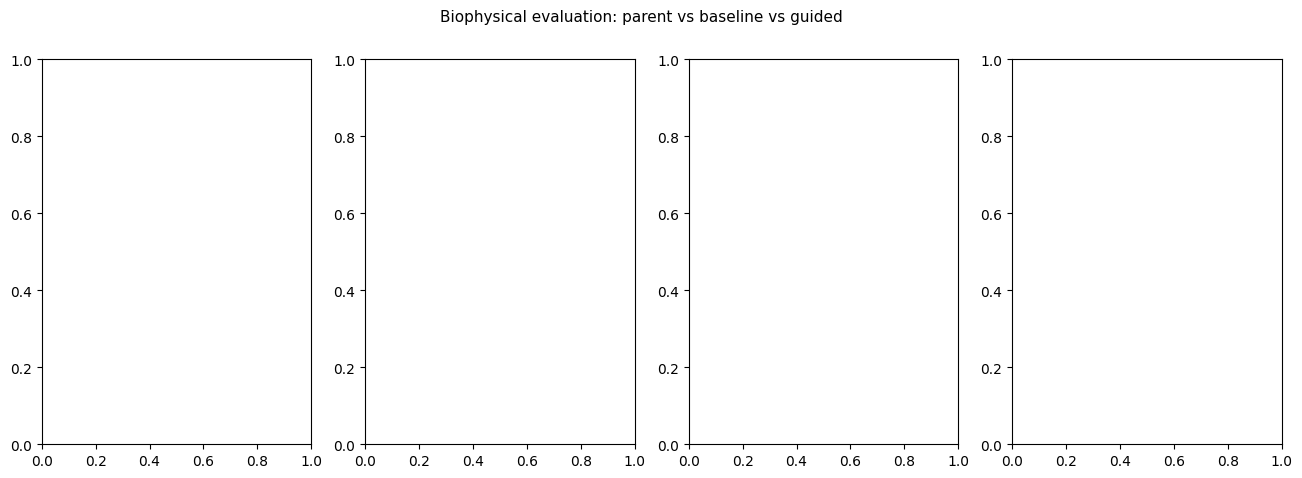

In [17]:
# ── Figure: Biophysical evaluation — parent vs baseline vs guided ─────────────
# Reproduces the style shown in the provided reference figures.

COLORS = {
    'Parent':   '#E8896A',   # salmon/coral
    'Baseline': '#B8D4C8',   # muted teal
    'Guided':   '#7BC4B8',   # teal
}

def box_data(col):
    return compare_df[col].dropna().values if col in compare_df.columns else np.array([])

def box_data_b(col):
    return compare_df_binding[col].dropna().values if col in compare_df_binding.columns else np.array([])

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Biophysical evaluation: parent vs baseline vs guided', fontsize=11)

panel_specs = [
    # (ax, title, data_fn, col_parent, col_baseline, col_guided, ylabel)
    (axes[0], 'Oracle HIC',    box_data,   'oracle_hic_parent',  'oracle_hic_baseline',  'oracle_hic_guided',  'Oracle HIC'),
    (axes[1], 'Oracle AC-SINS',box_data,   'oracle_sins_parent', 'oracle_sins_baseline', 'oracle_sins_guided', 'Oracle AC-SINS (↓ better)'),
    (axes[2], 'CamSol solubility', box_data, 'camsol_parent',   'camsol_baseline',      'camsol_guided',      'CamSol solubility'),
    (axes[3], 'SAP score (↓ better)', box_data, 'sap_parent',   'sap_baseline',         'sap_guided',         'SAP score (↓ better)'),
]

xtick_labels = ['Parent', 'Baseline\n(AbLang2)', 'Guided\n(flow)']

for ax, title, dfn, pc, bc, gc in panel_specs:
    d_parent   = dfn(pc)
    d_baseline = dfn(bc)
    d_guided   = dfn(gc)

    data_sets = [d_parent, d_baseline, d_guided]
    bp = ax.boxplot(
        [d for d in data_sets if len(d) > 0],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
    )

    colors_list = [COLORS['Parent'], COLORS['Baseline'], COLORS['Guided']]
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['Parent'],   label='Parent'),
    Patch(facecolor=COLORS['Baseline'], label='Baseline (AbLang2 only)'),
    Patch(facecolor=COLORS['Guided'],   label='Guided (flow + AbLang2)'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=8,
           framealpha=0.8, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig(CACHE('biophysical_evaluation_parent_vs_baseline_vs_guided.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Biophysical figure saved.')

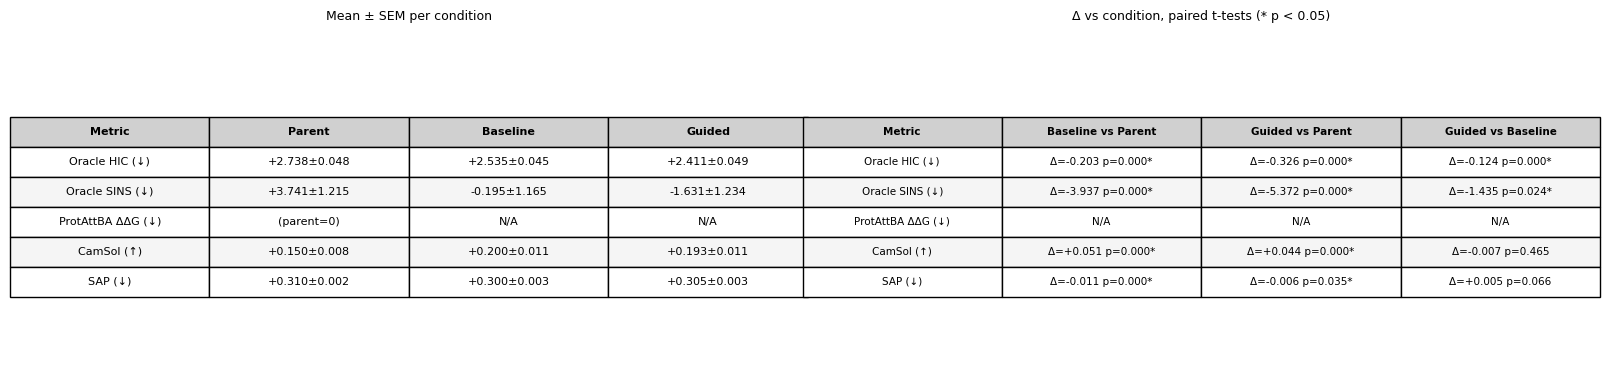

Statistical table figure saved.


In [18]:
# ── Figure: Statistical summary table (paired t-tests) ───────────────────────
# Reproduces the table format shown in the reference image (right panel).

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Left table: mean ± SEM per condition ---
rows_left = []
metrics_short = [
    ('Oracle HIC (↓)',   'oracle_hic',    compare_df,         True),
    ('Oracle SINS (↓)',  'oracle_sins',   compare_df,         True),
    ('CamSol (↑)',       'camsol',        compare_df,         True),
    ('SAP (↓)',          'sap',           compare_df,         True),
]

cols_left = ['Metric', 'Parent', 'Baseline', 'Guided']
table_data_left = []
for display, base, df_use, has_parent in metrics_short:
    row = [display]
    for suf in ['_parent', '_baseline', '_guided']:
        col = f'{base}{suf}'
        if col in df_use.columns:
            v = df_use[col].dropna()
            row.append(f'{v.mean():+.3f}±{v.sem():.3f}')
        else:
            row.append('N/A')
    table_data_left.append(row)

# ProtAttBA row
for suf_disp, suf in [('Baseline', '_baseline'), ('Guided', '_guided'), ('Flow-only', '_flow_only')]:
    col = f'ddG_protattba{suf}'
    pass

prot_row = ['ProtAttBA ΔΔG (↓)']
for suf in ['', '_baseline', '_guided']:
    if suf == '':
        prot_row.append('(parent=0)')
    else:
        col = f'ddG_protattba{suf}'
        if col in compare_df_binding.columns:
            v = compare_df_binding[col].dropna()
            prot_row.append(f'{v.mean():+.3f}±{v.sem():.3f}')
        else:
            prot_row.append('N/A')
table_data_left.insert(2, prot_row)

ax = axes[0]
ax.axis('off')
tbl = ax.table(
    cellText=table_data_left,
    colLabels=cols_left,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#D0D0D0')
        cell.set_text_props(weight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')
ax.set_title('Mean ± SEM per condition', fontsize=9, pad=10)

# --- Right table: Δ vs Parent with p-values ---
ax2 = axes[1]
ax2.axis('off')

cols_right = ['Metric', 'Baseline vs Parent', 'Guided vs Parent', 'Guided vs Baseline']
table_data_right = []

def delta_pval_str(df_use, col_a, col_b):
    a = df_use[col_a].dropna()
    b = df_use[col_b].loc[df_use[col_a].notna()]
    if len(a) < 5: return 'N/A'
    try:
        d = (a - b).mean()
        p = ttest_rel(a, b)[1]
        star = '*' if p < 0.05 else ''
        return f'Δ={d:+.3f} p={p:.3f}{star}'
    except:
        return 'N/A'

for display, base, df_use, _ in metrics_short:
    row = [display]
    # Baseline vs Parent
    row.append(delta_pval_str(df_use, f'{base}_baseline', f'{base}_parent'))
    # Guided vs Parent
    row.append(delta_pval_str(df_use, f'{base}_guided', f'{base}_parent'))
    # Guided vs Baseline
    row.append(delta_pval_str(df_use, f'{base}_guided', f'{base}_baseline'))
    table_data_right.append(row)

# ProtAttBA row (no parent baseline, compare absolute values)
p_row = ['ProtAttBA ΔΔG (↓)']
for col_a, col_b in [
    ('ddG_protattba_baseline', None),
    ('ddG_protattba_guided',   None),
    ('ddG_protattba_guided',   'ddG_protattba_baseline'),
]:
    if col_a in compare_df_binding.columns:
        if col_b is None:
            v = compare_df_binding[col_a].dropna()
            p_row.append(f'mean={v.mean():+.3f}')
        else:
            p_row.append(delta_pval_str(compare_df_binding, col_a, col_b))
    else:
        p_row.append('N/A')
table_data_right.insert(2, p_row)

tbl2 = ax2.table(
    cellText=table_data_right,
    colLabels=cols_right,
    loc='center',
    cellLoc='center',
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(7.5)
tbl2.scale(1.2, 1.6)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor('#D0D0D0')
        cell.set_text_props(weight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')
ax2.set_title('Δ vs condition, paired t-tests (* p < 0.05)', fontsize=9, pad=10)

plt.tight_layout()
plt.savefig(CACHE('statistical_summary_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Statistical table figure saved.')

NameError: name 'legend_elements' is not defined

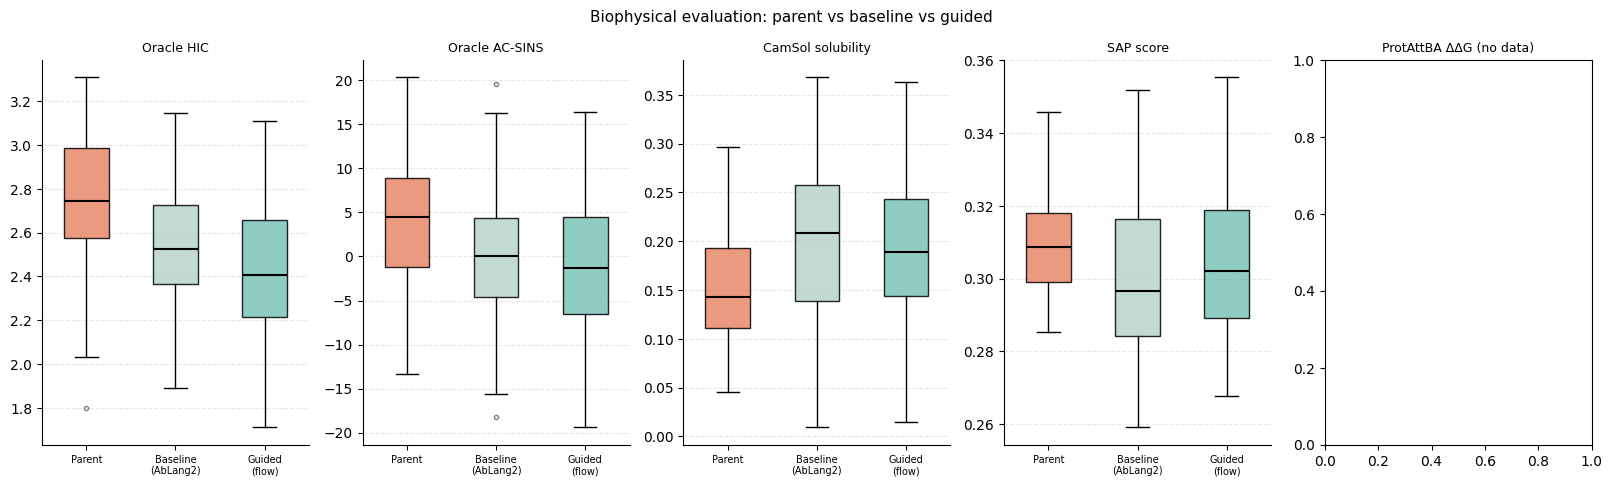

In [19]:
# ── Combined biophysical + ProtAttBA figure (5-panel) ────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Biophysical evaluation: parent vs baseline vs guided', fontsize=11)

panel_specs_5 = [
    (axes[0], 'Oracle HIC',       box_data,   'oracle_hic_parent',  'oracle_hic_baseline',  'oracle_hic_guided'),
    (axes[1], 'Oracle AC-SINS',   box_data,   'oracle_sins_parent', 'oracle_sins_baseline', 'oracle_sins_guided'),
    (axes[2], 'CamSol solubility',box_data,   'camsol_parent',      'camsol_baseline',      'camsol_guided'),
    (axes[3], 'SAP score',        box_data,   'sap_parent',         'sap_baseline',         'sap_guided'),
    (axes[4], 'ProtAttBA ΔΔG',    box_data_b, None,
     'ddG_protattba_baseline', 'ddG_protattba_guided'),
]

for row_data in panel_specs_5:
    ax, title, dfn, pc, bc, gc = row_data
    d_parent   = dfn(pc) if pc else np.array([])
    d_baseline = dfn(bc) if bc else np.array([])
    d_guided   = dfn(gc) if gc else np.array([])

    plot_data = [(d, c) for d, c in [
        (d_parent,   COLORS['Parent']),
        (d_baseline, COLORS['Baseline']),
        (d_guided,   COLORS['Guided']),
    ] if len(d) > 0]

    if not plot_data:
        ax.set_title(f'{title} (no data)', fontsize=9)
        continue

    bp = ax.boxplot(
        [d for d, _ in plot_data],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
    )
    for patch, (_, color) in zip(bp['boxes'], plot_data):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    n_boxes = len(plot_data)
    # Skip parent for ProtAttBA (no parent ΔΔG)
    if pc is None:
        xlbls = ['Baseline\n(AbLang2)', 'Guided\n(flow)']
    else:
        xlbls = ['Parent', 'Baseline\n(AbLang2)', 'Guided\n(flow)']
    ax.set_xticklabels(xlbls[:n_boxes], fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.legend(handles=legend_elements, loc='upper right', fontsize=8,
           framealpha=0.8, bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig(CACHE('biophysical_5panel_with_protattba.png'), dpi=150, bbox_inches='tight')
plt.show()
print('5-panel figure saved.')

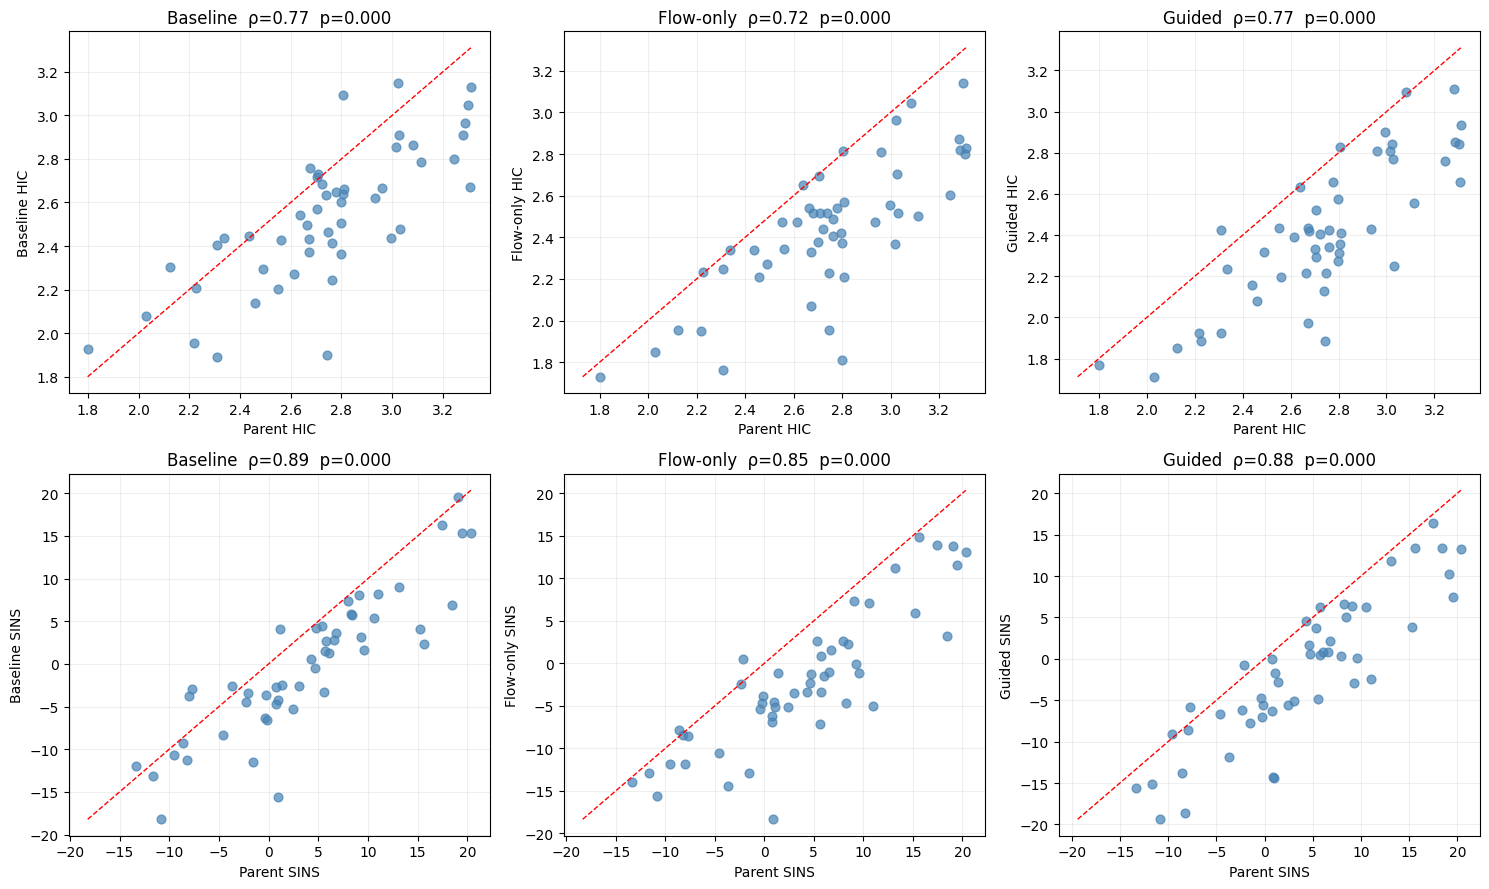

Oracle scatter plots saved.


In [20]:
# ── Oracle scatter plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row_i, (metric, pcol) in enumerate([
        ('HIC',  'oracle_hic_parent'),
        ('SINS', 'oracle_sins_parent')]):
    for ax, (label, suffix) in zip(axes[row_i], CONDITIONS_EVAL):
        col = f'oracle_{metric.lower()}{suffix}'
        if col not in compare_df.columns or pcol not in compare_df.columns:
            ax.set_title(f'{label} N/A'); continue
        x = compare_df[pcol].values; y = compare_df[col].values
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]
        if len(x) < 3: ax.set_title(f'{label} (n<3)'); continue
        mn = min(x.min(), y.min()); mx = max(x.max(), y.max())
        ax.scatter(x, y, alpha=0.7, s=40, color='steelblue')
        ax.plot([mn,mx],[mn,mx], 'r--', lw=1)
        rho, p = spearmanr(x, y)
        ax.set(xlabel=f'Parent {metric}', ylabel=f'{label} {metric}',
               title=f'{label}  ρ={rho:.2f}  p={p:.3f}')
        ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(CACHE('oracle_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Oracle scatter plots saved.')

In [ ]:
# ── Save final results ────────────────────────────────────────────────────────
compare_df.to_csv(f'{EVAL_DIR}/compare_df_final.csv', index=False)
compare_df_binding.to_csv(f'{EVAL_DIR}/compare_df_binding_final.csv', index=False)
print('Saved compare_df_final.csv and compare_df_binding_final.csv')

print('\n' + '='*80)
print('EVALUATION COMPLETE')
print('='*80)
print(f'Test antibodies: {len(compare_df)}  |  With antigen (ProtAttBA): {len(compare_df_binding)}')
print()
print('Key results (Δ vs parent, mean ± SEM):')
for label, suffix in CONDITIONS_EVAL:
    cols_to_check = [
        ('Oracle HIC',    f'oracle_hic{suffix}',    'oracle_hic_parent',   compare_df),
        ('Oracle SINS',   f'oracle_sins{suffix}',   'oracle_sins_parent',  compare_df),
        ('ProtAttBA ΔΔG', f'ddG_protattba{suffix}', None,                  compare_df_binding),
        ('CamSol',        f'camsol{suffix}',         'camsol_parent',       compare_df),
        ('SAP',           f'sap{suffix}',            'sap_parent',          compare_df),
    ]
    print(f'  [{label}]')
    for name, col, pcol, df_use in cols_to_check:
        if col not in df_use.columns: continue
        if pcol and pcol in df_use.columns:
            d = (df_use[col] - df_use[pcol]).dropna()
            print(f'    {name:<18} Δ={d.mean():+.3f} ± {d.sem():.3f}')
        else:
            v = df_use[col].dropna()
            if len(v):
                print(f'    {name:<18} mean={v.mean():+.3f} ± {v.sem():.3f}  '
                      f'improved={(v<0).sum()}/{len(v)}')